# Testing the visualizations

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

In [7]:

ds = xr.open_dataset("unified_annual_carbon_dataset_2015_2024.nc")
out_root = Path("csv_by_variable_and_time")
out_root.mkdir(parents=True, exist_ok=True)

def detect_spatial_dims(da):
    if "lat" in da.dims and "lon" in da.dims:
        return "lat", "lon"
    if "latitude" in da.dims and "longitude" in da.dims:
        return "latitude", "longitude"
    raise ValueError(f"Unsupported spatial dims for {da.name}: {da.dims}")

def time_to_label(t):
    t_arr = np.array(t)
    if np.issubdtype(t_arr.dtype, np.integer):
        return str(int(t))
    try:
        return np.datetime_as_string(np.datetime64(t), unit="D")
    except Exception:
        return str(t)

for var_name, da in ds.data_vars.items():
    if "time" not in da.dims:
        continue

    lat_dim, lon_dim = detect_spatial_dims(da)
    var_out = out_root / var_name
    var_out.mkdir(parents=True, exist_ok=True)

    for t in ds["time"].values:
        da_t = da.sel(time=t)

        lat_vals = da_t[lat_dim].values
        lon_vals = da_t[lon_dim].values
        vals = da_t.values  # 2D array: [lat, lon] or [latitude, longitude]

        # Build flat table directly from array + meshgrid
        lon_grid, lat_grid = np.meshgrid(lon_vals, lat_vals)
    
        vals = np.nan_to_num(da_t.values, nan=0.0, posinf=0.0, neginf=0.0)

        df = pd.DataFrame({
            "lat": lat_grid.ravel(),
            "lon": lon_grid.ravel(),
            var_name: vals.reshape(-1),
        })
        df[var_name] = df[var_name].fillna(0.0)

        out_file = var_out / f"{var_name}_time={time_to_label(t)}.csv"
        df.to_csv(out_file, index=False)#, compression="snappy")

        # Optional sanity check
        non_null = df[var_name].notna().sum()
        if non_null == 0:
            print(f"Warning: {var_name} at time={t} is all NaN in source data")

    print(f"Wrote {var_name}")

Wrote growth_rate
Wrote emission
Wrote gosif
Wrote delta_emission
Wrote delta_gosif
Wrote cams_xco2
Wrote growth_err
Wrote mean_co2


In [3]:
check = pd.read_csv("csv_by_variable_and_time\\emission\\emission_time=2015.csv")
print(check.head())
print(check["emission"].isna().mean(), "fraction NaN")
print(check["emission"].describe())

    lat    lon  emission
0 -89.5 -179.5       0.0
1 -89.5 -178.5       0.0
2 -89.5 -177.5       0.0
3 -89.5 -176.5       0.0
4 -89.5 -175.5       0.0
0.0 fraction NaN
count    6.480000e+04
mean     5.650678e+03
std      4.572364e+04
min      0.000000e+00
25%      1.124687e+00
50%      3.841523e+01
75%      2.440732e+02
max      3.544554e+06
Name: emission, dtype: float64


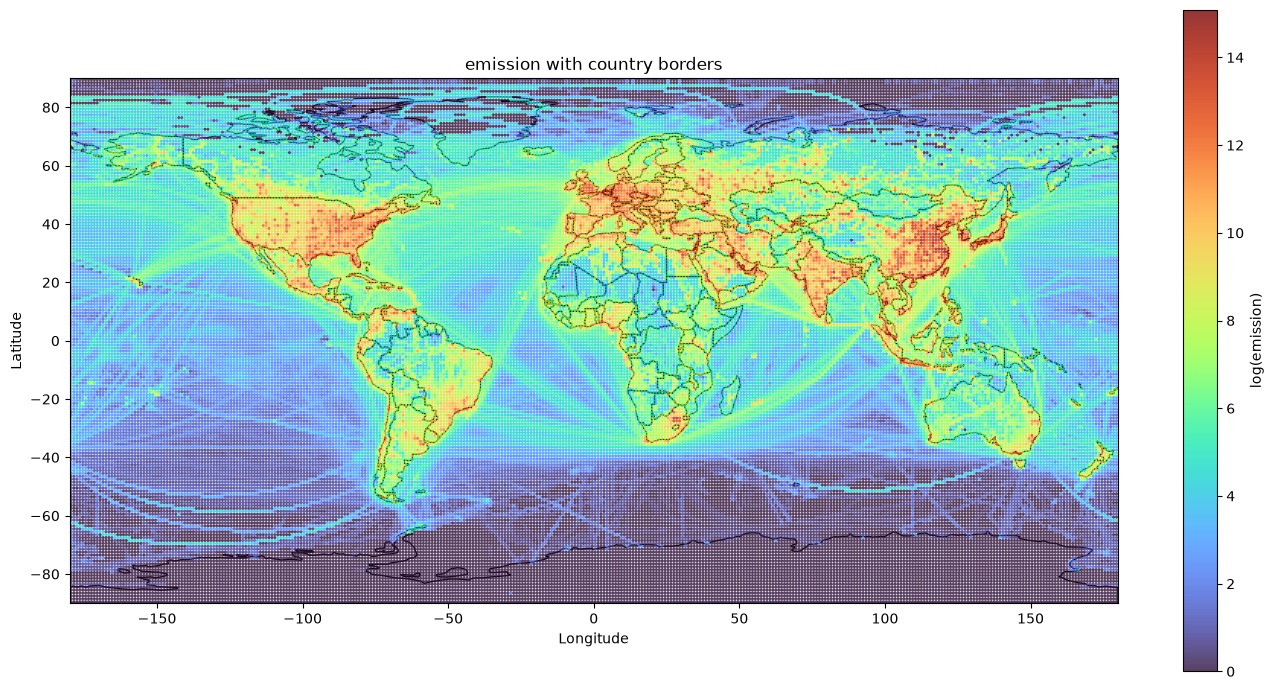

In [5]:
import geopandas as gpd
from pathlib import Path

# Cache borders locally after first download
borders_path = Path("ne_110m_admin_0_countries.gpkg")
if not borders_path.exists():
    world = gpd.read_file(
        "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
    )
    world.to_file(borders_path, driver="GPKG")
else:
    world = gpd.read_file(borders_path)

value_cols = [c for c in check.columns if c not in ["lat", "lon"]]
value_col = value_cols[0]

# Keep only positive values for log scale
plot_df = check[check[value_col] >= 0].dropna(subset=["lat", "lon", value_col]).copy()

fig, ax = plt.subplots(figsize=(14, 7))

# 1) Draw country borders first (background layer)
world.plot(
    ax=ax,
    facecolor="none",       # transparent fill
    edgecolor="black",
    linewidth=1,
    alpha=1
)

# 2) Scatter the data on top
sc = ax.scatter(
    plot_df["lon"],
    plot_df["lat"],
    c=np.log1p(plot_df[value_col]),   # log1p safe for 0s
    s=5,
    cmap="turbo",
    linewidths=0,
    alpha=0.8,
    zorder=2                # ensure data sits above borders
)

plt.colorbar(sc, ax=ax, label=f"log({value_col})")
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"{value_col} with country borders")
plt.tight_layout()
plt.show()

In [12]:
import numpy as np
import pandas as pd

from bokeh.io import output_notebook, show
from bokeh.models import (
    ColumnDataSource, LogColorMapper, ColorBar, BasicTicker, LogTicker,
    NumeralTickFormatter, HoverTool
)
from bokeh.plotting import figure
from bokeh.palettes import Turbo256

output_notebook()

# 1) Detect the value column (everything except lat/lon)
value_cols = [c for c in check.columns if c not in ["lat", "lon"]]
if not value_cols:
    raise ValueError("No data variable column found in check.")
value_col = value_cols[0]

# 2) Keep only finite rows and positive values (required for log scale)
plot_df = check[["lat", "lon", value_col]].copy()
plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna(subset=["lat", "lon", value_col])
plot_df = plot_df[plot_df[value_col] > 0].copy()

if plot_df.empty:
    raise ValueError("No positive non-NaN values available for log-scale plotting.")

# 3) Optional: quantile clipping for better color contrast
#    This prevents a few extreme values from washing out the map.
low_q, high_q = plot_df[value_col].quantile([0.01, 0.99])
plot_df["val_clipped"] = plot_df[value_col].clip(lower=low_q, upper=high_q)

# 4) Build color mapper on clipped values
vmin = float(plot_df["val_clipped"].min())
vmax = float(plot_df["val_clipped"].max())
if vmin <= 0:
    vmin = float(plot_df.loc[plot_df["val_clipped"] > 0, "val_clipped"].min())

mapper = LogColorMapper(palette=Turbo256, low=vmin, high=vmax)

source = ColumnDataSource(plot_df)

# 5) High-resolution interactive figure
p = figure(
    title=f"{value_col} map (log color, non-NaN positive values)",
    width=700,     # increase resolution
    height=325,     # increase resolution
    x_axis_label="Longitude",
    y_axis_label="Latitude",
    tools="pan,wheel_zoom,box_zoom,lasso_select,reset,save",
    active_scroll="wheel_zoom",
    match_aspect=True
)

# Small markers for dense grid; higher alpha improves visual blending
r = p.circle(
    x="lon",
    y="lat",
    source=source,
    size=3,
    alpha=0.85,
    line_alpha=0,
    fill_color={"field": "val_clipped", "transform": mapper}
)

hover = HoverTool(
    renderers=[r],
    tooltips=[
        ("lon", "@lon{0.00}"),
        ("lat", "@lat{0.00}"),
        (value_col, f"@{value_col}{{0.000}}"),
        ("clipped", "@val_clipped{0.000}")
    ]
)
p.add_tools(hover)

color_bar = ColorBar(
    color_mapper=mapper,
    ticker=LogTicker(),
    formatter=NumeralTickFormatter(format="0.00a"),
    label_standoff=8,
    location=(0, 0),
    title=f"{value_col} (log scale)"
)
p.add_layout(color_bar, "right")

p.grid.visible = True
p.grid.grid_line_alpha = 0.2

show(p)

Loading BokehJS ...

In [6]:
import numpy as np
import pandas as pd
import geopandas as gpd

from pathlib import Path
from bokeh.io import output_notebook, show
from bokeh.models import (
    ColumnDataSource, GeoJSONDataSource, LinearColorMapper, LogColorMapper,
    ColorBar, NumeralTickFormatter, HoverTool
)
from bokeh.plotting import figure
from bokeh.palettes import Turbo256

output_notebook()

# ---- User options ----
# Choose: "linear" or "log"
color_scale = "log"

# Fixed marker size so points behave like regular gridpoints
point_size = 3

# 1) Build plotting table from selected variable
value_cols = [c for c in check.columns if c not in ["lat", "lon"]]
if not value_cols:
    raise ValueError("No data variable column found in check.")
value_col = value_cols[0]

plot_df = check[["lat", "lon", value_col]].replace([np.inf, -np.inf], np.nan).dropna()
if plot_df.empty:
    raise ValueError("No valid points available after dropping NaN/Inf values.")

# 2) Load country polygons (includes land outlines)
borders_path = Path("ne_110m_admin_0_countries.gpkg")
if not borders_path.exists():
    world = gpd.read_file(
        "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
    )
    world.to_file(borders_path, driver="GPKG")
else:
    world = gpd.read_file(borders_path)

# Keep only valid geometries in geographic CRS
world = world.to_crs("EPSG:4326")
world = world[world.geometry.notna() & ~world.geometry.is_empty].copy()
world_source = GeoJSONDataSource(geojson=world.to_json())

# 3) Configure color mapping
vals = plot_df[value_col].astype(float).values

if color_scale not in ["linear", "log"]:
    raise ValueError("color_scale must be either 'linear' or 'log'.")

if color_scale == "log":
    # Log scale requires strictly positive values
    mask = vals > 0
    plot_df = plot_df.loc[mask].copy()
    vals = plot_df[value_col].astype(float).values

    if vals.size == 0:
        raise ValueError("No positive values available for log color scale.")

    vmin = float(vals.min())
    vmax = float(vals.max())
    if vmin == vmax:
        vmax = vmin + 1e-9

    mapper = LogColorMapper(palette=Turbo256, low=vmin, high=vmax)
    colorbar_title = f"{value_col} (log)"
else:
    vmin = float(vals.min())
    vmax = float(vals.max())
    if vmin == vmax:
        vmax = vmin + 1e-9

    mapper = LinearColorMapper(palette=Turbo256, low=vmin, high=vmax)
    colorbar_title = f"{value_col} (linear)"

source = ColumnDataSource({
    "lon": plot_df["lon"],
    "lat": plot_df["lat"],
    "value": vals,
})

# 4) Bokeh map with country/land outlines + gridpoint dots
p = figure(
    title=f"{value_col} map with country outlines (Bokeh, {color_scale} color)",
    width=950,
    height=500,
    x_axis_label="Longitude",
    y_axis_label="Latitude",
    tools="pan,wheel_zoom,box_zoom,reset,save",
    active_scroll="wheel_zoom",
    match_aspect=True,
    x_range=(-180, 180),
    y_range=(-60, 85),
)

# Draw land/country outlines first to keep geographic context visible
p.patches(
    "xs", "ys",
    source=world_source,
    fill_alpha=0.04,
    fill_color="#d9e2ec",
    line_color="#374151",
    line_width=0.8,
    line_alpha=0.9,
    level="underlay",
)

# Fixed-size points: only color corresponds to value
r = p.scatter(
    x="lon",
    y="lat",
    source=source,
    size=point_size,
    alpha=0.9,
    line_alpha=0,
    fill_color={"field": "value", "transform": mapper},
)

hover = HoverTool(
    renderers=[r],
    tooltips=[
        ("lon", "@lon{0.00}"),
        ("lat", "@lat{0.00}"),
        (value_col, "@value{0.000}"),
    ],
)
p.add_tools(hover)

color_bar = ColorBar(
    color_mapper=mapper,
    formatter=NumeralTickFormatter(format="0.00a"),
    label_standoff=8,
    location=(0, 0),
    title=colorbar_title,
    width=12,
)
p.add_layout(color_bar, "right")

p.grid.visible = True
p.grid.grid_line_alpha = 0.2

show(p)

Loading BokehJS ...

In [12]:
output_filename = "emissions_interactive_map.html"
fig.write_html(output_filename, config={"scrollZoom": True}, auto_open=True)